# Data Augmentation

## 1. Imports

In [1]:
import pandas as pd
import json
import uuid
import os
import time
from PIL import Image
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

from utils.utils_preproc import *
from utils.utils_augmentation import *
from utils.utils_model import *

In [2]:
# 1. Load the CSVs without 'dx_encoded' (since it's not in the file)
train_df = pd.read_csv('data/train_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
val_df = pd.read_csv('data/val_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
test_df = pd.read_csv('data/test_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path','dx']]

# 2. Re-create the encoded column using the loaded dictionary
train_df["dx_encoded"] = train_df["dx"].map(label2idx).astype(int)
val_df["dx_encoded"] = val_df["dx"].map(label2idx).astype(int)
test_df["dx_encoded"] = test_df["dx"].map(label2idx).astype(int)

In [3]:
train_df.head()

,image_id,dataset,lesion_id,cleaned_path,dx,dx_encoded
0,ISIC_0024306,vidir_molemax,HAM_0000550,./data\HAM10000_cleaned\train\ISIC_0024306_cle...,nv,5
1,ISIC_0024307,vidir_molemax,HAM_0003577,./data\HAM10000_cleaned\train\ISIC_0024307_cle...,nv,5
2,ISIC_0024308,vidir_molemax,HAM_0001477,./data\HAM10000_cleaned\train\ISIC_0024308_cle...,nv,5
3,ISIC_0024309,vidir_molemax,HAM_0000484,./data\HAM10000_cleaned\train\ISIC_0024309_cle...,nv,5
4,ISIC_0024311,vidir_molemax,HAM_0000981,./data\HAM10000_cleaned\train\ISIC_0024311_cle...,nv,5


In [4]:
train_df = train_df.rename(columns={'cleaned_path': 'image_path'})
val_df = val_df.rename(columns={'cleaned_path': 'image_path'})
test_df = test_df.rename(columns={'cleaned_path': 'image_path'})

In [5]:
train_df.head()

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
0,ISIC_0024306,vidir_molemax,HAM_0000550,./data\HAM10000_cleaned\train\ISIC_0024306_cle...,nv,5
1,ISIC_0024307,vidir_molemax,HAM_0003577,./data\HAM10000_cleaned\train\ISIC_0024307_cle...,nv,5
2,ISIC_0024308,vidir_molemax,HAM_0001477,./data\HAM10000_cleaned\train\ISIC_0024308_cle...,nv,5
3,ISIC_0024309,vidir_molemax,HAM_0000484,./data\HAM10000_cleaned\train\ISIC_0024309_cle...,nv,5
4,ISIC_0024311,vidir_molemax,HAM_0000981,./data\HAM10000_cleaned\train\ISIC_0024311_cle...,nv,5


## 2. Offline Augmentation

In the offline augmentation approach, augmented images are pre-generated before training and stored alongside the original dataset. Each class is assigned a dedicated augmentation strategy proportional to its degree of underrepresentation, ranging from light geometric transformations for moderately imbalanced classes to aggressive color, texture, and spatial distortions for the most underrepresented ones. The augmented dataset is then fed to the model as a fixed set of images, meaning the model sees the same synthetic versions every epoch.

To ground this expansion, we utilized **Square Root Balancing** to determine the augmentation multipliers, providing a statistically smoothed balance that boosts minority classes while preserving essential distributional priors. We objectively assigned our transformation strategies based on these results: classes requiring higher multipliers were subjected to more aggressive spatial and color distortions to maximize feature variance. This ensured that for even the rarest classes, the model was forced to learn robust, generalized patterns rather than memorizing the limited set of original samples.

In [6]:
augmentation_multiplier_map, strategy_map, save_strategy_map = get_square_root_maps(train_df, target_size=4500)
augmentation_multiplier_map

{'nv': 1, 'bkl': 2, 'mel': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}

In [8]:
# TEST (CPU - 2min)
output_csv = os.path.join(base_path, "augmented_metadata.csv")

aug_train_df = run_augmentation_pipeline(
            train_df=train_df,
            undersample=True,
            undersample_size=4500,
            output_path=output_csv,
            augmentation_map=augmentation_multiplier_map,
            save_strategy_map=save_strategy_map
        )

AUGMENTATION PIPELINE

[1/3] Generating augmented images...
Submitting task for augmenting bkl (multiplier: 2)
Submitting task for augmenting mel (multiplier: 2)
Submitting task for augmenting bcc (multiplier: 3)
Submitting task for augmenting akiec (multiplier: 4)
Submitting task for augmenting vasc (multiplier: 5)
Submitting task for augmenting df (multiplier: 6)


Generating all augmented images: 100%|██████████| 6/6 [00:28<00:00,  4.73s/it]

Generated 5353 augmented images

[2/3] Undersampling 'nv' to 4500 samples...
Undersampled to 4500 samples

[3/3] Combining datasets...
Final dataset size: 13059 samples

Saved to: ./data\augmented_metadata.csv

FINAL CLASS DISTRIBUTION
dx
akiec    1244
bcc      1461
bkl      2154
df        864
mel      2066
nv       4500
vasc      770
Name: count, dtype: int64


### 2.2 Visuals

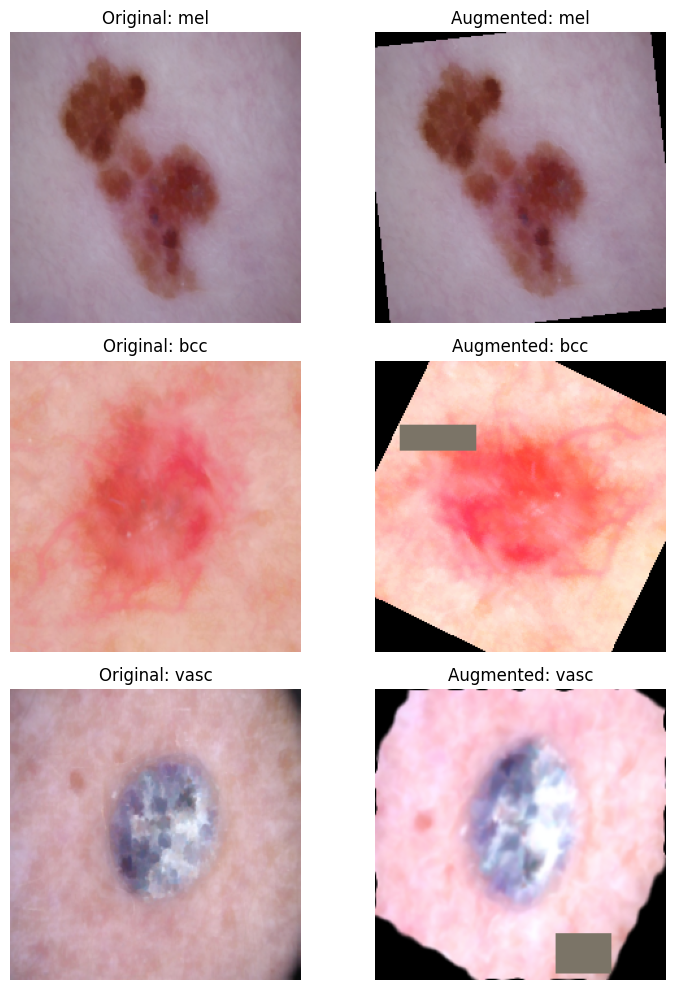

In [7]:
test_labels = ['mel', 'bcc', 'vasc']
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

for i, label in enumerate(test_labels):
    sample_path = train_df[train_df['dx'] == label].sample(1).iloc[0]['image_path']

    # open once
    with Image.open(sample_path) as img:
        img = img.convert("RGB")
        original = transforms.Resize((224, 224))(img)
        aug_tensor = strategy_map[label](original)

    aug_final = denormalize(aug_tensor, means, stds)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original: {label}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(aug_final)
    axes[i, 1].set_title(f"Augmented: {label}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

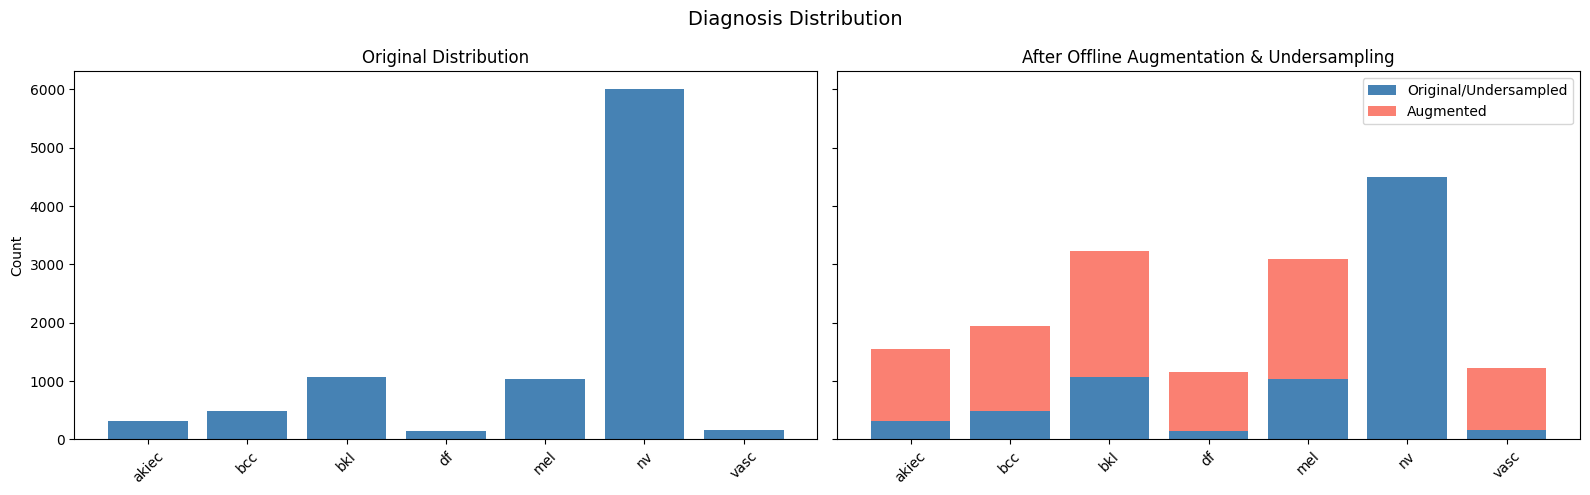

In [8]:
labels = sorted(aug_train_df["dx"].unique())
 
# Get original counts (unmodified)
original_counts = [len(train_df[train_df["dx"] == l]) for l in labels]
 
# Get final counts from augmented dataframe
final_counts = [len(aug_train_df[aug_train_df["dx"] == l]) for l in labels]
 
# For right chart: separate undersampled/original from augmented
undersampled_or_original = []
augmented_only = []
for i, label in enumerate(labels):
    if label == 'nv':
        # nv was undersampled to 4500
        undersampled_or_original.append(4500)
        augmented_only.append(final_counts[i] - 4500)
    else:
        # Other classes: original count + augmentation
        undersampled_or_original.append(original_counts[i])
        augmented_only.append(final_counts[i] - original_counts[i])
 
x = np.arange(len(labels))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
 
# ── Left: Original Distribution
axes[0].bar(x, original_counts, color="steelblue")
axes[0].set_title("Original Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("Count")
 
# ── Right: After Augmentation & Undersampling (stacked)
axes[1].bar(x, undersampled_or_original, color="steelblue", label="Original/Undersampled")
axes[1].bar(x, augmented_only, bottom=undersampled_or_original, color="salmon", label="Augmented")
axes[1].set_title("After Offline Augmentation & Undersampling")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()
 
plt.suptitle("Diagnosis Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Online Augmentation

In the online augmentation approach, transformations are applied on-the-fly during training using Keras's ImageDataGenerator. Unlike the offline approach, augmented images are generated fresh each epoch, providing greater visual diversity over the course of training. 

However, this approach carries a notable limitation in this context: ImageDataGenerator does not support per-class augmentation strategies, meaning all classes receive the same transformation pipeline regardless of their degree of underrepresentation. As a result, the aggressive augmentations designed for extreme minority classes such as vasc and df are also applied to majority classes, and conversely, minority classes cannot receive stronger augmentation than the rest. This is an inherent constraint of the API rather than a design choice, and should be taken into account when interpreting the comparison between both approaches.

In [9]:
train_datagen_on = ImageDataGenerator(
    preprocessing_function=preprocess_imagenet,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    shear_range=10,
    fill_mode='nearest'
)

val_datagen_on = ImageDataGenerator(
    preprocessing_function=preprocess_imagenet
)

# 4. Augmentation Comparison 

To evaluate the impact of each augmentation strategy on model performance and computational efficiency, both approaches were trained under identical conditions: same model architecture, optimizer, learning rate, number of epochs, and batch size. Performance was assessed through the following metrics: 
- **Peak validation accuracy**: the best value recorded across all epochs, capturing the model's best achievable performance
- **Final validation accuracy**: the value at the last epoch, reflecting training stability and convergence
- **Average epoch training** and **batch processing times** quantify the computational overhead introduced by each approach. 

Together, these metrics provide a comprehensive basis for comparison, covering both the quality of the learned representations and the practical training costs associated with each augmentation strategy.

## 4.1 Setting Up

In [40]:
aug_train_df.sample(5)

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
1687,ISIC_0031012,original,HAM_0005389,./data\HAM10000_cleaned\train\ISIC_0031012_cle...,akiec,0
3919,ISIC_0026832,original,HAM_0000630,./data\HAM10000_cleaned\train\ISIC_0026832_cle...,nv,5
15665,AUG_vasc_3da8d8e6,augmented,AUG_LESION_vasc_98946e7d,./data\HAM10000_augmented\AUG_vasc_3da8d8e6.jpg,vasc,6
9649,AUG_mel_d457133a,augmented,AUG_LESION_mel_5e671d4a,./data\HAM10000_augmented\AUG_mel_d457133a.jpg,mel,4
16639,AUG_df_29c1e76a,augmented,AUG_LESION_df_062e53ac,./data\HAM10000_augmented\AUG_df_29c1e76a.jpg,df,3


In [ ]:
# Class weights
N_CLASSES = 7
BATCH_SIZE = 32
class_weights_dict = make_class_weights(aug_train_df)

In [ ]:
# Offline Dataset
train_ds = make_dataset_new(aug_train_df, shuffle=True, repeat=True)  
val_ds   = make_dataset_new(val_df)                               
test_ds  = make_dataset_new(test_df)

In [44]:
# Online Dataset
classes_ordered = [k for k, v in sorted(label2idx.items(), key=lambda x: x[1])]

train_gen_on = train_datagen_on.flow_from_dataframe(
    dataframe  = train_df,
    x_col      = 'image_path',
    y_col      = 'dx',
    target_size= (224, 224),
    batch_size = BATCH_SIZE,
    class_mode = 'sparse',
    classes    = classes_ordered,
    shuffle    = True
)

val_gen_on = val_datagen_on.flow_from_dataframe(
    dataframe  = val_df,
    x_col      = 'image_path',
    y_col      = 'dx',
    target_size= (224, 224),
    batch_size = BATCH_SIZE,
    class_mode = 'sparse',
    classes    = classes_ordered,
    shuffle    = False
)

Found 9214 validated image filenames belonging to 7 classes.
Found 1152 validated image filenames belonging to 7 classes.


## 4.2 Baseline Model

In [58]:
model_offline = keras.Sequential([
    keras.layers.Conv2D(16, 3, activation="relu", padding="same", input_shape=(224, 224, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.25),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(N_CLASSES)
])

model_offline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
EPOCHS = 10
SPE = 100
BATCH_SIZE = 32

In [61]:
# OFFLINE AUGMENTED DATASET
# CPU - ~10min
batch_time_cb_off = BatchTimeCallback()

history_offline = model_offline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=SPE,
    class_weight=class_weights_dict,
    callbacks=[batch_time_cb_off]
)

avg_batch_off = sum(batch_time_cb_off.batch_times) / len(batch_time_cb_off.batch_times)
avg_epoch_off = sum(batch_time_cb_off.epoch_times) / len(batch_time_cb_off.epoch_times)
print(f"Avg batch time (offline): {avg_batch_off:.4f} s/step")
print(f"Avg epoch time (offline): {avg_epoch_off:.1f} s")

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 128s 594ms/step - accuracy: 0.5128 - loss: 1.2291 - val_accuracy: 0.6944 - val_loss: 0.9433
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 573ms/step - accuracy: 0.4953 - loss: 1.1947 - val_accuracy: 0.6780 - val_loss: 1.0849
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 551ms/step - accuracy: 0.5066 - loss: 1.2077 - val_accuracy: 0.6970 - val_loss: 0.9371
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 524ms/step - accuracy: 0.5097 - loss: 1.1498 - val_accuracy: 0.6675 - val_loss: 1.0202
Epoch 5/10
 20/100 ━━━━━━━━━━━━━━━━━━━━ 45s 574ms/step - accuracy: 0.5240 - loss: 1.1422

: 

In [ ]:
model_online= keras.Sequential([
    keras.layers.Conv2D(16, 3, activation="relu", padding="same", input_shape=(224, 224, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.25),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(N_CLASSES)
])

model_online.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [ ]:
# ONLINE AUGMENTED DATASET
# CPU - ~15min
batch_time_cb_on = BatchTimeCallback()

history_online = model_online.fit(
    train_gen_on,
    validation_data = val_gen_on,
    epochs          = EPOCHS,
    steps_per_epoch = SPE,
    class_weight    = class_weights_dict,
    callbacks       = [batch_time_cb_on]
)

avg_batch_on = sum(batch_time_cb_on.batch_times) / len(batch_time_cb_on.batch_times)
avg_epoch_on = sum(batch_time_cb_on.epoch_times) / len(batch_time_cb_on.epoch_times)
print(f"\nAvg batch time (online): {avg_batch_on:.4f} s/step")
print(f"Avg epoch time (online): {avg_epoch_on:.1f} s")

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 95s 876ms/step - accuracy: 0.5929 - loss: 1.0555 - val_accuracy: 0.6936 - val_loss: 1.5103
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 995ms/step - accuracy: 0.6266 - loss: 1.0202 - val_accuracy: 0.6727 - val_loss: 1.3968
Epoch 3/10
 88/100 ━━━━━━━━━━━━━━━━━━━━ 11s 994ms/step - accuracy: 0.6317 - loss: 0.9719

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 94s 947ms/step - accuracy: 0.6335 - loss: 0.9720 - val_accuracy: 0.6849 - val_loss: 1.2280
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6428 - loss: 0.9315 - val_accuracy: 0.6189 - val_loss: 1.1542
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 802ms/step - accuracy: 0.6438 - loss: 0.9088 - val_accuracy: 0.6840 - val_loss: 1.0363
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 849ms/step - accuracy: 0.6214 - loss: 0.9404 - val_accuracy: 0.6875 - val_loss: 1.0654
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 100s 999ms/step - accuracy: 0.6447 - loss: 0.9015 - val_accuracy: 0.7005 - val_loss: 0.9814
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 894ms/step - accuracy: 0.6356 - loss: 0.9065 - val_accuracy: 0.6806 - val_loss: 1.0606
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - accuracy: 0.6269 - loss: 0.9116 - val_accuracy: 0.6918 - val_loss: 1.0211
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 808ms/step - accuracy: 0.6397 - loss: 0.9035 - val

## 4.3 Performance Comparison

In [ ]:
pd.DataFrame({
    "Offline Augmentation": [
        f"{len(aug_train_df)}",
        "2 minutes",
        f"{avg_batch_off:.4f}",
        f"{avg_epoch_off:.1f}",
        f"{history_offline.history['val_accuracy'][-1]:.4f}",
        f"{max(history_offline.history['val_accuracy']):.4f}"
    ],
    "Online Augmentation": [
        f"{len(train_df)}",
        "-",
        f"{avg_batch_on:.4f}",
        f"{avg_epoch_on:.1f}",
        f"{history_online.history['val_accuracy'][-1]:.4f}",
        f"{max(history_online.history['val_accuracy']):.4f}"

    ]
}, index=['Dataset Size', 'Pre-generation Time', 'Avg Batch Time (s/step)', 'Avg Epoch Time (s)', 'Final Val Accuracy', 'Peak Val Accuracy'])

,Offline Augmentation,Online Augmentation
Dataset Size,16717,9214
Pre-generation Time,2 minutes,-
Avg Batch Time (s/step),0.5456,0.8478
Avg Epoch Time (s),59.1,89.4
Final Val Accuracy,0.6832,0.6788
Peak Val Accuracy,0.6936,0.7005


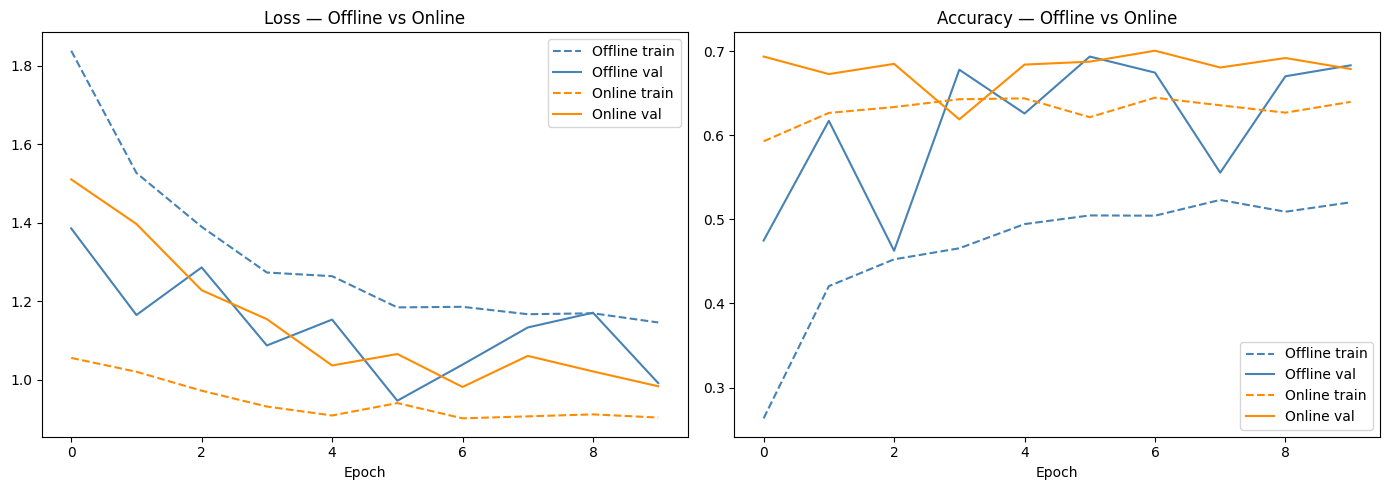

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_offline.history["loss"],     label="Offline train", linestyle="--", color="steelblue")
axes[0].plot(history_offline.history["val_loss"], label="Offline val",                  color="steelblue")
axes[0].plot(history_online.history["loss"],       label="Online train",  linestyle="--", color="darkorange")
axes[0].plot(history_online.history["val_loss"],   label="Online val",                   color="darkorange")
axes[0].set_title("Loss — Offline vs Online")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_offline.history["accuracy"],     label="Offline train", linestyle="--", color="steelblue")
axes[1].plot(history_offline.history["val_accuracy"], label="Offline val",                  color="steelblue")
axes[1].plot(history_online.history["accuracy"],       label="Online train",  linestyle="--", color="darkorange")
axes[1].plot(history_online.history["val_accuracy"],   label="Online val",                   color="darkorange")
axes[1].set_title("Accuracy — Offline vs Online")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

The results suggest that both approaches achieve comparable validation performance, with offline augmentation being significantly faster while training per epoch. 

The speed advantage of offline augmentation is partly attributable to its larger dataset of pre-generated images being loaded directly from disk, avoiding the per-batch augmentation overhead. Accounting for the 2-minute preprocessing time, the total computational cost remains competitive. 

Given its greater training stability, faster iteration cycles, and per-class augmentation strategies that online augmentation cannot fully replicate with ImageDataGenerator, **the offline augmentation approach was selected** for all subsequent experiments.